# IDS 705 — Group 10: DASYNet Grid Attack Study
## Spatial Patch Evaluation · Fine-tuned DASYNet · PneumoniaMNIST+

Evaluates how localized corruption affects the fine-tuned DASYNet model.
Each of the 5 selected attacks is applied to one 3×3 grid patch at a time
at **Level 3 only**, producing a spatial sensitivity heatmap per attack.

| Model | Weights |
|-------|---------|
| Fine-tuned DASYNet (1-channel, 224×224) | `dasynet_finetuned.pth` |


## 0. Setup

In [ ]:
!pip install medmnist --quiet

import os, io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import medmnist
from medmnist import INFO, PneumoniaMNIST
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch  : {torch.__version__}')
print(f'device : {device}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 2.9 MB/s eta 0:00:00
torch  : 2.10.0+cpu
device : cpu


## 1. Mount Drive & Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

FT_WEIGHTS = '/content/drive/MyDrive/ML_final/dasynet_finetuned.pth'

DATA_FLAG = 'pneumoniamnist'
IMG_SIZE  = 224
DATA_ROOT = os.path.expanduser('~/.medmnist')
BATCH_SIZE = 64

info      = INFO[DATA_FLAG]
n_classes = len(info['label'])

print(f'Weights : {FT_WEIGHTS}')
print(f'Classes : {n_classes}')


Mounted at /content/drive
Weights : /content/drive/MyDrive/ML_final/dasynet_finetuned.pth
Classes : 2


## 2. DASYNet Architecture & Load Weights

In [ ]:
class DASYNET(nn.Module):
    def __init__(self, in_channels=1, num_classes=2):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.global_pool = nn.AdaptiveAvgPool2d((3, 3))
        self.flatten     = nn.Flatten()
        self.classifier  = nn.Sequential(
            nn.Linear(64 * 3 * 3, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x)
        return self.classifier(self.flatten(x))


model = DASYNET(in_channels=1, num_classes=n_classes).to(device)
model.load_state_dict(torch.load(FT_WEIGHTS, map_location=device))
model.eval()
print('Fine-tuned DASYNet loaded successfully.')


Fine-tuned DASYNet loaded successfully.


## 3. Attack Definitions

In [ ]:
# The 5 selected attacks evaluated at Level 3 only
# Level index 2 = Level 3 (0-indexed)
ATTACK_LEVELS = {
    'FGSM'               : [0.001, 0.005, 0.01, 0.015, 0.02],
    'Gamma Underexposed' : [1.5,   2.0,   3.0,  4.0,   5.0 ],
    'Contrast Low'       : [0.8,   0.6,   0.4,  0.3,   0.2 ],
    'Gamma Overexposed'  : [0.9,   0.7,   0.5,  0.3,   0.1 ],
    'Brightness Bright'  : [0.1,   0.2,   0.3,  0.4,   0.5 ],
}

# For FGSM the grid uses Level 1 (epsilon=0.001) since
# FGSM Level 1 is the selected severity for single-attack comparison.
# All other attacks use Level 3 (index 2).
ATTACK_GRID_LEVEL = {
    'FGSM'               : 0,   # Level 1, epsilon=0.001
    'Gamma Underexposed' : 2,   # Level 3, gamma=3.0
    'Contrast Low'       : 2,   # Level 3, alpha=0.4
    'Gamma Overexposed'  : 2,   # Level 3, gamma=0.5
    'Brightness Bright'  : 2,   # Level 3, delta=+0.3
}

SELECTED_ATTACKS = list(ATTACK_LEVELS.keys())
GRID_SECTIONS = [
    'Top-Left',   'Top-Center',   'Top-Right',
    'Mid-Left',   'Mid-Center',   'Mid-Right',
    'Bot-Left',   'Bot-Center',   'Bot-Right',
]

FLAG_THRESHOLD = 0.05


def apply_gamma(t, gamma):
    t_01    = (t + 1) / 2
    t_gamma = torch.pow(t_01.clamp(min=1e-8), gamma)
    return (t_gamma * 2 - 1).clamp(-1, 1)


def make_clean_transform():
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('L')),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])


def make_patch_tensor_fn(attack_name, level_idx):
    """Returns a function: PIL patch -> corrupted tensor (1, patch_h, patch_w)."""
    param = ATTACK_LEVELS[attack_name][level_idx]

    # No Resize here — patch is already cropped to its natural size
    to_tensor_norm = transforms.Compose([
        transforms.Lambda(lambda img: img.convert('L')),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    def corrupt_fn(patch_pil):
        t = to_tensor_norm(patch_pil)   # (1, patch_h, patch_w)
        if attack_name == 'Brightness Bright':
            return torch.clamp(t + param, -1.0, 1.0)
        elif attack_name == 'Contrast Low':
            return torch.clamp(t * param, -1.0, 1.0)
        elif attack_name in ('Gamma Overexposed', 'Gamma Underexposed'):
            return apply_gamma(t, param)
        return t

    return corrupt_fn


print('Attack definitions loaded.')
print(f'Selected attacks : {SELECTED_ATTACKS}')


Attack definitions loaded.
Selected attacks : ['FGSM', 'Gamma Underexposed', 'Contrast Low', 'Gamma Overexposed', 'Brightness Bright']


## 4. Grid Patch Dataset & Inference

In [ ]:
# Grid section -> (row_start_frac, col_start_frac) in 3x3 layout
GRID_COORDS = {
    'Top-Left'  : (0, 0), 'Top-Center'  : (0, 1), 'Top-Right'  : (0, 2),
    'Mid-Left'  : (1, 0), 'Mid-Center'  : (1, 1), 'Mid-Right'  : (1, 2),
    'Bot-Left'  : (2, 0), 'Bot-Center'  : (2, 1), 'Bot-Right'  : (2, 2),
}

class PatchCorruptDataset(Dataset):
    """Applies a corruption to one 3x3 grid patch of each image."""
    def __init__(self, base_ds, section, corrupt_fn):
        self.base_ds    = base_ds
        self.section    = section
        self.corrupt_fn = corrupt_fn
        row, col        = GRID_COORDS[section]
        patch_h = IMG_SIZE // 3
        patch_w = IMG_SIZE // 3
        self.box = (col * patch_w, row * patch_h,
                    (col + 1) * patch_w, (row + 1) * patch_h)
        self.clean_t = make_clean_transform()

    def __len__(self): return len(self.base_ds)

    def __getitem__(self, i):
        img_pil, label = self.base_ds[i]
        img_l = img_pil.convert('L').resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        # Corrupt the patch region only
        patch = img_l.crop(self.box)
        corrupted_patch_t = self.corrupt_fn(patch)  # (1, patch_h, patch_w)
        full_t = self.clean_t(img_l)                # (1, 224, 224)
        r0, c0 = GRID_COORDS[self.section]
        ph = IMG_SIZE // 3
        pw = IMG_SIZE // 3
        row_s = r0 * ph
        col_s = c0 * pw
        full_t[:, row_s:row_s+ph, col_s:col_s+pw] = corrupted_patch_t
        return full_t, torch.tensor(int(label), dtype=torch.long)


def compute_metrics(scores, labels):
    preds = scores[:, 1] if scores.ndim == 2 else scores
    y_pred = (preds > 0.5).astype(int)
    y_true = labels.squeeze().astype(int)
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'auroc'    : roc_auc_score(y_true, preds),
    }


def run_inference(model, loader):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            logits = model(imgs.to(device))
            scores = torch.softmax(logits, dim=1)
            all_scores.append(scores.cpu().numpy())
            all_labels.append(lbls.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)


# Clean baseline
raw_test = PneumoniaMNIST(split='test', transform=None,
                          download=True, root=DATA_ROOT, size=IMG_SIZE)
clean_loader = DataLoader(
    type('D', (), {
        '__len__': lambda s: len(raw_test),
        '__getitem__': lambda s, i: (make_clean_transform()(raw_test[i][0].convert('L').resize((IMG_SIZE,IMG_SIZE), Image.NEAREST)), torch.tensor(int(raw_test[i][1]), dtype=torch.long))
    })(),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

# Simpler: load clean via transform directly
clean_ds = PneumoniaMNIST(split='test', transform=make_clean_transform(),
                          download=False, root=DATA_ROOT, size=IMG_SIZE)
clean_loader = DataLoader(clean_ds, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)
clean_scores, clean_labels = run_inference(model, clean_loader)
clean_metrics = compute_metrics(clean_scores, clean_labels)
clean_acc = clean_metrics['accuracy']

print(f'Clean baseline accuracy : {clean_acc:.4f}')
print(f'Clean baseline AUROC    : {clean_metrics["auroc"]:.4f}')


100%|██████████| 214M/214M [00:58<00:00, 3.65MB/s]


Clean baseline accuracy : 0.8974
Clean baseline AUROC    : 0.9669


## 5. Grid Patch Evaluation

5 attacks × 9 patches = 45 experiments. Level 3 for all attacks except FGSM (Level 1).
Flag threshold: accuracy drop > 5% vs. clean baseline.


In [ ]:
results   = {}   # {attack: {section: metrics}}
flag_rows = []

for attack_name in SELECTED_ATTACKS:
    level_idx  = ATTACK_GRID_LEVEL[attack_name]
    param      = ATTACK_LEVELS[attack_name][level_idx]
    level_label = f'L{level_idx + 1}'
    results[attack_name] = {}

    print(f'\n[{attack_name}]  {level_label}  param={param}')
    print(f'  {"Section":<15} {"Acc":>7} {"Recall":>7} {"Drop":>7}')

    for section in GRID_SECTIONS:

        if attack_name == 'FGSM':
            # FGSM requires gradient computation on full image;
            # for the patch version we apply sign-noise to patch pixels only.
            # We reuse the same epsilon as a pixel-delta approximation.
            epsilon = param
            def fgsm_corrupt_fn(patch_pil, eps=epsilon):
                t = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.5], std=[0.5])
                ])(patch_pil.convert('L'))
                noise = eps * t.sign()
                return torch.clamp(t + noise, -1.0, 1.0)
            corrupt_fn = fgsm_corrupt_fn
        else:
            corrupt_fn = make_patch_tensor_fn(attack_name, level_idx)

        ds = PatchCorruptDataset(raw_test, section, corrupt_fn)
        loader = DataLoader(ds, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=0)
        scores, labels = run_inference(model, loader)
        m = compute_metrics(scores, labels)
        results[attack_name][section] = m

        drop = clean_acc - m['accuracy']
        flag = ' ⚠️' if drop > FLAG_THRESHOLD else ''
        print(f'  {section:<15} {m["accuracy"]:>7.4f} {m["recall"]:>7.4f} {drop:>+7.4f}{flag}')

        if drop > FLAG_THRESHOLD:
            flag_rows.append({
                'Attack'  : attack_name,
                'Level'   : level_label,
                'Position': section,
                'Acc Drop': round(drop, 4),
                'Accuracy': round(m['accuracy'], 4),
                'Recall'  : round(m['recall'], 4),
            })

print('\n' + '=' * 60)
print('Grid evaluation complete.')



[FGSM]  L1  param=0.001
  Section             Acc  Recall    Drop


/tmp/ipykernel_5884/3871609633.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return full_t, torch.tensor(int(label), dtype=torch.long)


  Top-Left         0.8974  0.9872 +0.0000


/tmp/ipykernel_5884/3871609633.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return full_t, torch.tensor(int(label), dtype=torch.long)


  Top-Center       0.8974  0.9872 +0.0000


...

  Bot-Left         0.9199  0.9385 -0.0224


/tmp/ipykernel_5884/3871609633.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return full_t, torch.tensor(int(label), dtype=torch.long)


  Bot-Center       0.8542  0.9949 +0.0433


/tmp/ipykernel_5884/3871609633.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return full_t, torch.tensor(int(label), dtype=torch.long)


  Bot-Right        0.8622  0.9974 +0.0353

Grid evaluation complete.


## 6. Spatial Sensitivity Heatmap — Level 3

One heatmap per attack. Color encodes accuracy drop from clean baseline.
Red = larger drop (more sensitive), Blue = smaller drop or improvement, White = no change.


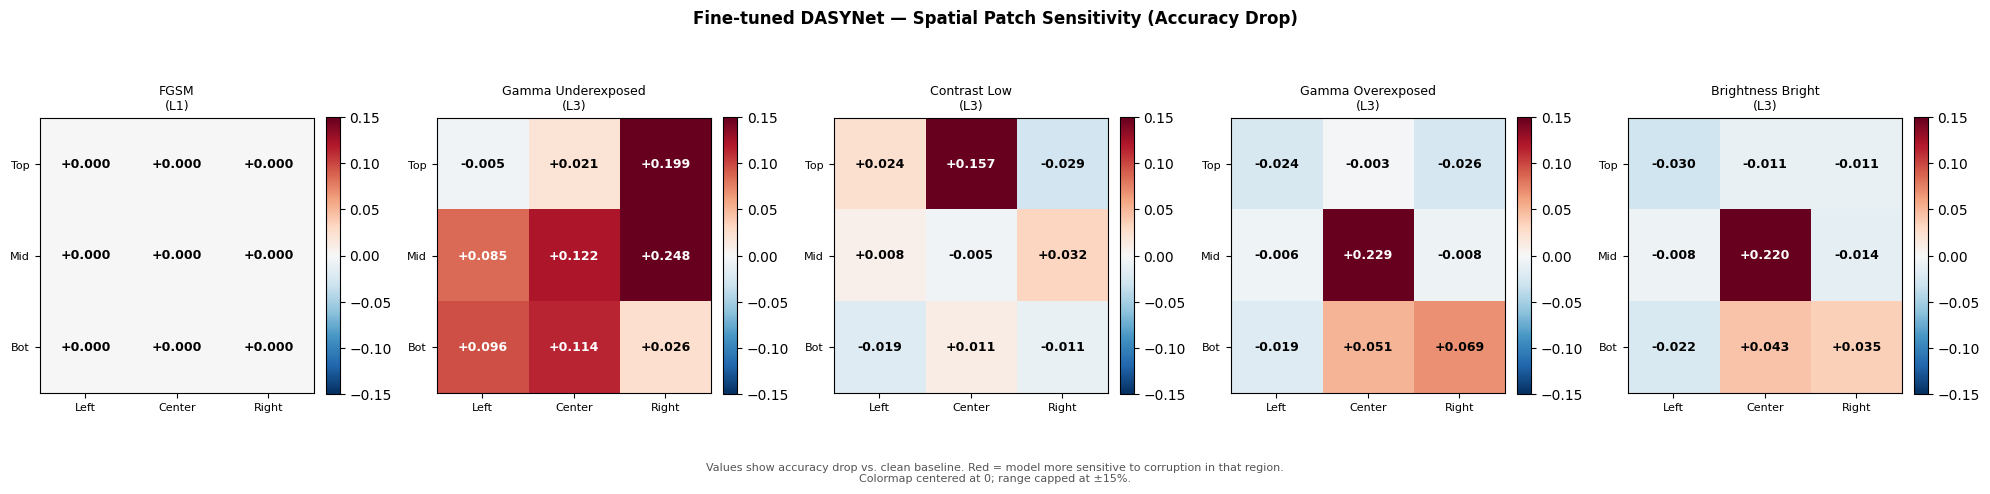

Saved: dasynet_grid_heatmap_L3.png


In [ ]:
GRID_ORDER = [
    ['Top-Left',  'Top-Center',  'Top-Right' ],
    ['Mid-Left',  'Mid-Center',  'Mid-Right' ],
    ['Bot-Left',  'Bot-Center',  'Bot-Right' ],
]

n_attacks = len(SELECTED_ATTACKS)
fig, axes = plt.subplots(1, n_attacks, figsize=(4 * n_attacks, 4.5))
fig.patch.set_facecolor('white')

vmax = 0.15   # cap color range at 15% drop for readability

for ax, attack_name in zip(axes, SELECTED_ATTACKS):
    level_idx   = ATTACK_GRID_LEVEL[attack_name]
    level_label = f'L{level_idx + 1}'
    drop_grid   = np.array([
        [clean_acc - results[attack_name][s]['accuracy'] for s in row]
        for row in GRID_ORDER
    ])

    im = ax.imshow(drop_grid, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(3):
        for j in range(3):
            val = drop_grid[i, j]
            color = 'white' if abs(val) > vmax * 0.5 else 'black'
            ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')

    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(['Left', 'Center', 'Right'], fontsize=8)
    ax.set_yticklabels(['Top', 'Mid', 'Bot'], fontsize=8)
    ax.set_title(f'{attack_name}\n({level_label})', fontsize=9, pad=6)

plt.suptitle('Fine-tuned DASYNet — Spatial Patch Sensitivity (Accuracy Drop)',
             fontsize=12, y=1.01, fontweight='bold')
plt.tight_layout()
fig.text(
    0.5, -0.04,
    'Values show accuracy drop vs. clean baseline. Red = model more sensitive to corruption in that region.\n'
    'Colormap centered at 0; range capped at ±15%.',
    ha='center', fontsize=8, color='#555555'
)
plt.savefig('dasynet_grid_heatmap_L3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dasynet_grid_heatmap_L3.png')


## 7. Flagging Report — Accuracy Drop > 5%

In [ ]:
print('=' * 65)
print('⚠️  PATCH FLAGGING REPORT — Accuracy Drop > 5% — Fine-tuned DASYNet')
print('=' * 65)

if flag_rows:
    df_flags = pd.DataFrame(flag_rows).sort_values('Acc Drop', ascending=False)
    df_flags = df_flags.set_index(['Attack', 'Position'])
    df_flags.to_csv('dasynet_grid_flags.csv')
    print(df_flags.to_string())
    print(f'\nTotal flagged combinations : {len(flag_rows)}')
    print('Saved: dasynet_grid_flags.csv')

    pos_counts = Counter([r['Position'] for r in flag_rows])
    print('\nMost vulnerable grid positions (flag count):')
    for pos, cnt in pos_counts.most_common():
        print(f'  {pos:<15s}: {cnt} flag(s)')

    atk_counts = Counter([r['Attack'] for r in flag_rows])
    print('\nMost spatially damaging attacks (flag count):')
    for atk, cnt in atk_counts.most_common():
        print(f'  {atk:<22s}: {cnt} flag(s)')
else:
    print('  No patch/attack combination exceeded 5% accuracy drop.')
    print('  Fine-tuned DASYNet is spatially robust to localized Level 3 corruption.')


⚠️  PATCH FLAGGING REPORT — Accuracy Drop > 5% — Fine-tuned DASYNet
                              Level  Acc Drop  Accuracy  Recall
Attack             Position                                    
Gamma Underexposed Mid-Right     L3    0.2484    0.6490  1.0000
Gamma Overexposed  Mid-Center    L3    0.2292    0.6683  1.0000
Brightness Bright  Mid-Center    L3    0.2196    0.6779  1.0000
Gamma Underexposed Top-Right     L3    0.1987    0.6987  1.0000
Contrast Low       Top-Center    L3    0.1571    0.7404  1.0000
Gamma Underexposed Mid-Center    L3    0.1218    0.7756  0.6641
                   Bot-Center    L3    0.1138    0.7837  0.6872
                   Bot-Left      L3    0.0962    0.8013  0.9974
                   Mid-Left      L3    0.0849    0.8125  1.0000
Gamma Overexposed  Bot-Right     L3    0.0689    0.8285  1.0000
                   Bot-Center    L3    0.0513    0.8462  0.9974

Total flagged combinations : 11
Saved: dasynet_grid_flags.csv

Most vulnerable grid positions (flag